# one-time creation of dataset

In [1]:
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Load MEG data
fname = "/Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/main.fif"
raw = mne.io.read_raw_fif(fname, preload=True)
raw.filter(1., 40.)

# Load behavioral data
df_behav = pd.read_csv('/Users/roman/PycharmProjects/brain_data/data/15.10.24/1/alena_final_untitled_2024-10-15_13h00.00.308.csv')

# Extract start times
fix_cross_start = df_behav['fix_cross.started'].dropna().values
print(f"Loaded {len(fix_cross_start)} fixation cross starts")
print(f"MEG data duration: {raw.times[-1]:.2f} seconds")

Opening raw data file /Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/main.fif...
    Read a total of 8 projection items:
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
    Range : 55000 ... 1630999 =     55.000 ...  1630.999 secs
Ready.
Opening raw data file /Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/main-1.fif...
    Read a total of 8 projection items:
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
   

In [2]:
true_events = df_behav['fix_cross.started'].dropna().values

channel_name = raw.ch_names[0]
sfreq = raw.info['sfreq']
data, times = raw[channel_name, :]
data = data.flatten()

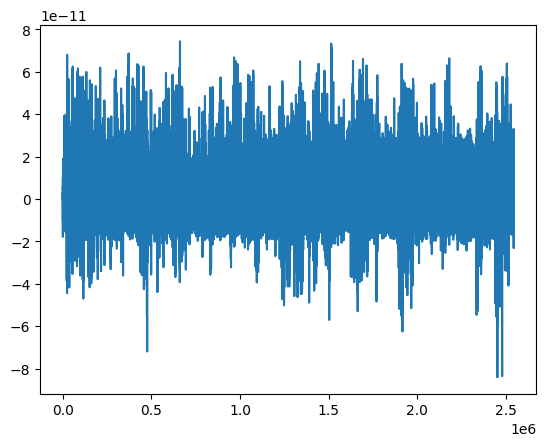

In [3]:
plt.plot(data)

In [8]:
np.save('brain_data_timeseries.npy', data)

In [9]:
np.save('true_events.npy', true_events)

# np load

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
import warnings

warnings.filterwarnings('ignore')

data = np.load('brain_data_timeseries.npy')
true_events = np.load('true_events.npy')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.spatial.distance import mahalanobis
from scipy.linalg import pinv
from scipy.stats import wasserstein_distance

# ============================================================
# FEATURE EXTRACTION
# ============================================================

def extract_features(x):

    f = {}

    # ----------------------------------------
    # basic statistics
    # ----------------------------------------

    f['mean'] = np.mean(x)
    f['std'] = np.std(x)
    f['var'] = np.var(x)

    f['rms'] = np.sqrt(np.mean(x**2))

    f['min'] = np.min(x)
    f['max'] = np.max(x)

    f['peak_to_peak'] = np.ptp(x)

    # ----------------------------------------
    # shape / movement
    # ----------------------------------------

    dx = np.diff(x)

    f['line_length'] = np.sum(np.abs(dx))

    f['mean_abs_diff'] = np.mean(np.abs(dx))

    f['diff_std'] = np.std(dx)

    # ----------------------------------------
    # zero crossing
    # ----------------------------------------

    f['zero_crossing_rate'] = (
        np.sum(np.diff(np.sign(x)) != 0) / len(x)
    )

    # ----------------------------------------
    # Hjorth
    # ----------------------------------------

    if np.std(x) > 0:

        mobility = np.std(dx) / np.std(x)

        ddx = np.diff(dx)

        complexity = (
            np.std(ddx) / np.std(dx) / mobility
            if np.std(dx) > 0 and mobility > 0
            else 0
        )

    else:
        mobility = 0
        complexity = 0

    f['hjorth_mobility'] = mobility
    f['hjorth_complexity'] = complexity

    # ----------------------------------------
    # autocorrelation
    # ----------------------------------------

    if len(x) > 1:
        f['acf_lag1'] = np.corrcoef(x[:-1], x[1:])[0, 1]
    else:
        f['acf_lag1'] = 0

    if np.isnan(f['acf_lag1']):
        f['acf_lag1'] = 0

    return np.array(list(f.values())), list(f.keys())


# ============================================================
# DIVERGENCE FUNCTIONS
# ============================================================

def l2_distance(left, right):
    return np.linalg.norm(left - right)


def mahalanobis_distance(left, right, cov_inv):
    return mahalanobis(left, right, cov_inv)


def relative_change(left, right):

    eps = 1e-8

    rel = np.abs(right - left) / (np.abs(left) + eps)

    return np.mean(rel)

## just to show the result

In [3]:
change_indices = (true_events * 1000).astype(int)
change_indices

array([  22891,   27639,   33271,   37953,   43085,   48500,   53515,
         58180,   63045,   68244,   72342,   77124,   82923,   86605,
         91120,   95036,  100967,  105432,  109864,  113813,  118762,
        122960,  128509,  133557,  137723,  143287,  147653,  153801,
        158416,  162348,  166630,  170896,  175294,  180859,  186841,
        192472,  195605,  199204,  202086,  205835,  210017,  213549,
        216798,  220031,  223630,  227945,  233027,  237925,  240474,
        244457,  249205,  253504,  257136,  262851,  267133,  271015,
        274564,  277197,  281229,  285594,  289160,  292775,  297240,
        301256,  306138,  310903,  314735,  319933,  323266,  328997,
        332680,  337395,  342277,  345909,  350741,  354656,  359122,
        363370,  368452,  374284,  379515,  383831,  388146,  393278,
        397826,  401892,  405457,  408840,  414521,  419386,  423152,
        429217,  433799,  439514,  445462,  451293,  457958,  462490,
        467588,  471

In [4]:
timestamps = np.arange(data.shape[0])
timestamps

array([      0,       1,       2, ..., 2542997, 2542998, 2542999],
      shape=(2543000,))

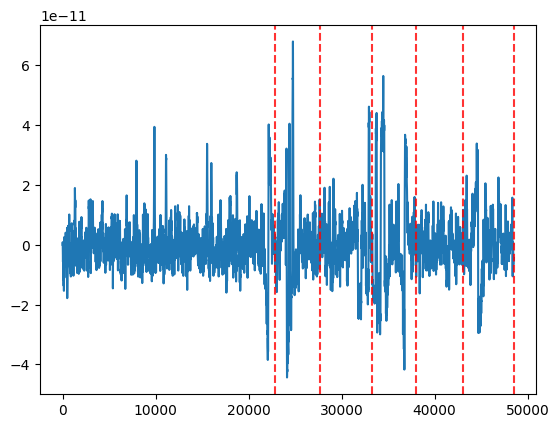

In [5]:
plt.plot(
    timestamps[timestamps < change_indices[5]],
    data[timestamps < change_indices[5]],
)

# Plot vertical lines for change points
for cp in change_indices[:6]:
    plt.axvline(
        cp,
        color='red',
        linestyle='--',
        alpha=0.8
    )

# w=50, s=10

In [14]:
WINDOW = 50
STEP = 10

In [25]:
timestamps = []
scores_l2 = []
scores_mahal = []
scores_rel = []

change_points = np.array(change_indices)

# collect all feature vectors first
all_features = []

for t in range(WINDOW, len(data) - WINDOW, STEP):

    left_window = data[t-WINDOW:t]
    right_window = data[t:t+WINDOW]

    left_feat, feature_names = extract_features(left_window)
    right_feat, _ = extract_features(right_window)

    all_features.append(left_feat)
    all_features.append(right_feat)

all_features = np.array(all_features)

In [26]:
# covariance for Mahalanobis
cov = np.cov(all_features.T)

# regularization
cov += np.eye(cov.shape[0]) * 1e-6

cov_inv = pinv(cov) # need not be the general identity matrix, but it maps all column vectors of matrix to themselves


# actual scoring loop
for t in range(WINDOW, len(data) - WINDOW, STEP):

    left_window = data[t-WINDOW:t]
    right_window = data[t:t+WINDOW]

    left_feat, _ = extract_features(left_window)
    right_feat, _ = extract_features(right_window)

    # ----------------------------------------
    # scores
    # ----------------------------------------

    s_l2 = l2_distance(left_feat, right_feat)

    s_mahal = mahalanobis_distance(
        left_feat,
        right_feat,
        cov_inv
    )

    s_rel = relative_change(left_feat, right_feat)

    timestamps.append(t)

    scores_l2.append(s_l2)
    scores_mahal.append(s_mahal)
    scores_rel.append(s_rel)

timestamps = np.array(timestamps)

scores_l2 = np.array(scores_l2)
scores_mahal = np.array(scores_mahal)
scores_rel = np.array(scores_rel)

## plot

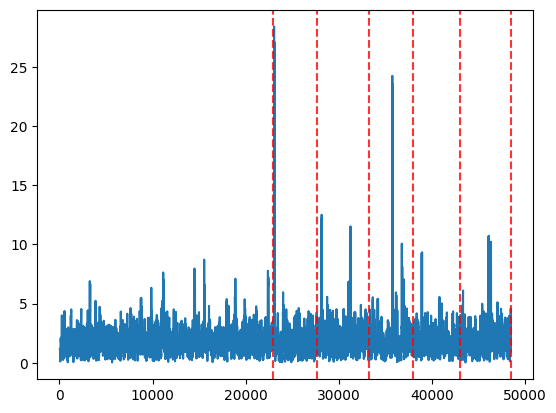

In [28]:
change_points_in_scores = change_points_in_scores = [cp // STEP for cp in change_indices]

plt.plot(
    timestamps[timestamps < change_indices[5]],
    scores_mahal[timestamps < change_indices[5]],
)

for cp in change_indices[:6]:
    plt.axvline(
        cp,
        color='red',
        linestyle='--',
        alpha=0.8
    )

## mean plot

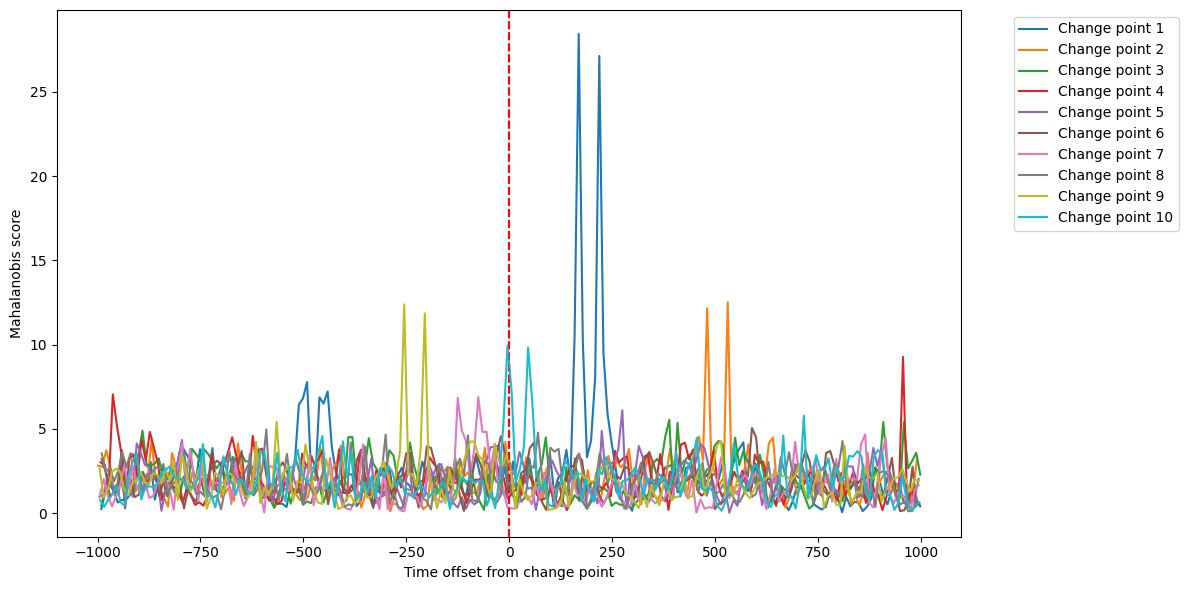

In [29]:
plt.figure(figsize=(12, 6))

for i in range(10):
    mask = (timestamps > change_indices[i] - 1000) & (timestamps < change_indices[i] + 1000)
    relative_time = timestamps[mask] - change_indices[i]  # offset from change point
    plt.plot(relative_time, scores_mahal[mask], label=f'Change point {i+1}')
    plt.axvline(0, color='red', linestyle='--', alpha=0.3)  # x=0 is the change point

plt.xlabel('Time offset from change point')
plt.ylabel('Mahalanobis score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# w=1000, s=10

In [30]:
WINDOW = 1000
STEP = 10

In [31]:
timestamps = []
scores_l2 = []
scores_mahal = []
scores_rel = []

change_points = np.array(change_indices)

# collect all feature vectors first
all_features = []

for t in range(WINDOW, len(data) - WINDOW, STEP):

    left_window = data[t-WINDOW:t]
    right_window = data[t:t+WINDOW]

    left_feat, feature_names = extract_features(left_window)
    right_feat, _ = extract_features(right_window)

    all_features.append(left_feat)
    all_features.append(right_feat)

all_features = np.array(all_features)

In [32]:
# covariance for Mahalanobis
cov = np.cov(all_features.T)

# regularization
cov += np.eye(cov.shape[0]) * 1e-6

cov_inv = pinv(cov) # need not be the general identity matrix, but it maps all column vectors of matrix to themselves


# actual scoring loop
for t in range(WINDOW, len(data) - WINDOW, STEP):

    left_window = data[t-WINDOW:t]
    right_window = data[t:t+WINDOW]

    left_feat, _ = extract_features(left_window)
    right_feat, _ = extract_features(right_window)

    # ----------------------------------------
    # scores
    # ----------------------------------------

    s_l2 = l2_distance(left_feat, right_feat)

    s_mahal = mahalanobis_distance(
        left_feat,
        right_feat,
        cov_inv
    )

    s_rel = relative_change(left_feat, right_feat)

    timestamps.append(t)

    scores_l2.append(s_l2)
    scores_mahal.append(s_mahal)
    scores_rel.append(s_rel)

timestamps = np.array(timestamps)

scores_l2 = np.array(scores_l2)
scores_mahal = np.array(scores_mahal)
scores_rel = np.array(scores_rel)

## plot

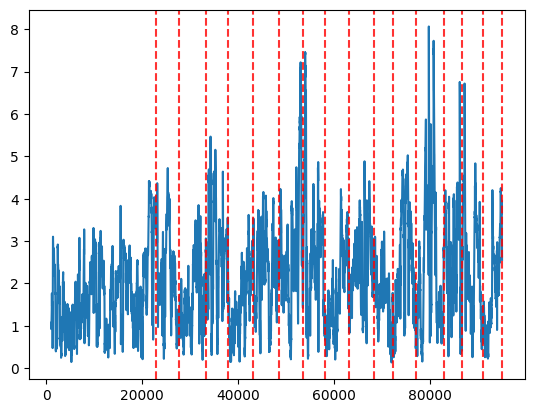

In [36]:
change_points_in_scores = change_points_in_scores = [cp // STEP for cp in change_indices]

plt.plot(
    timestamps[timestamps < change_indices[15]],
    scores_mahal[timestamps < change_indices[15]],
)

for cp in change_indices[:16]:
    plt.axvline(
        cp,
        color='red',
        linestyle='--',
        alpha=0.8
    )

## mean plot

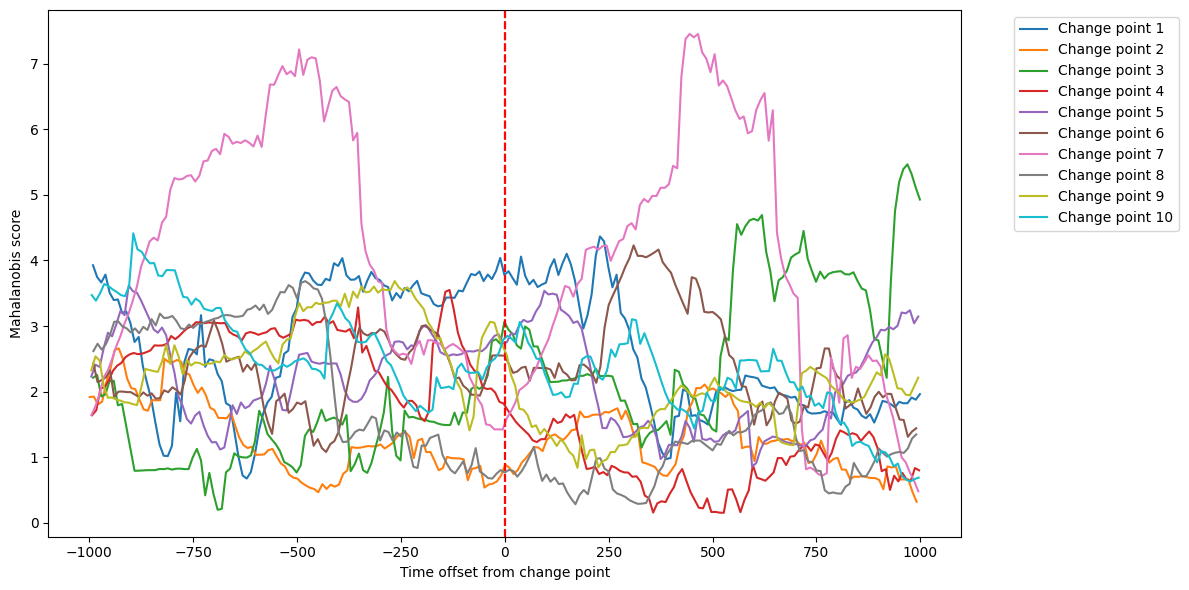

In [34]:
plt.figure(figsize=(12, 6))

for i in range(10):
    mask = (timestamps > change_indices[i] - 1000) & (timestamps < change_indices[i] + 1000)
    relative_time = timestamps[mask] - change_indices[i]  # offset from change point
    plt.plot(relative_time, scores_mahal[mask], label=f'Change point {i+1}')
    plt.axvline(0, color='red', linestyle='--', alpha=0.3)  # x=0 is the change point

plt.xlabel('Time offset from change point')
plt.ylabel('Mahalanobis score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# w=100, s=10

In [6]:
WINDOW = 100
STEP = 10

In [7]:
timestamps = []
scores_l2 = []
scores_mahal = []
scores_rel = []

change_points = np.array(change_indices)

# collect all feature vectors first
all_features = []

for t in range(WINDOW, len(data) - WINDOW, STEP):

    left_window = data[t-WINDOW:t]
    right_window = data[t:t+WINDOW]

    left_feat, feature_names = extract_features(left_window)
    right_feat, _ = extract_features(right_window)

    all_features.append(left_feat)
    all_features.append(right_feat)

all_features = np.array(all_features)

In [8]:
# covariance for Mahalanobis
cov = np.cov(all_features.T)

# regularization
cov += np.eye(cov.shape[0]) * 1e-6

cov_inv = pinv(cov) # need not be the general identity matrix, but it maps all column vectors of matrix to themselves


# actual scoring loop
for t in range(WINDOW, len(data) - WINDOW, STEP):

    left_window = data[t-WINDOW:t]
    right_window = data[t:t+WINDOW]

    left_feat, _ = extract_features(left_window)
    right_feat, _ = extract_features(right_window)

    # ----------------------------------------
    # scores
    # ----------------------------------------

    s_l2 = l2_distance(left_feat, right_feat)

    s_mahal = mahalanobis_distance(
        left_feat,
        right_feat,
        cov_inv
    )

    s_rel = relative_change(left_feat, right_feat)

    timestamps.append(t)

    scores_l2.append(s_l2)
    scores_mahal.append(s_mahal)
    scores_rel.append(s_rel)

timestamps = np.array(timestamps)

scores_l2 = np.array(scores_l2)
scores_mahal = np.array(scores_mahal)
scores_rel = np.array(scores_rel)

## plot

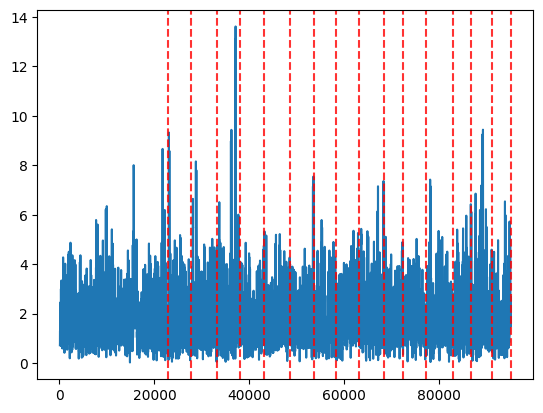

In [40]:
change_points_in_scores = change_points_in_scores = [cp // STEP for cp in change_indices]

plt.plot(
    timestamps[timestamps < change_indices[15]],
    scores_mahal[timestamps < change_indices[15]],
)

for cp in change_indices[:16]:
    plt.axvline(
        cp,
        color='red',
        linestyle='--',
        alpha=0.8
    )

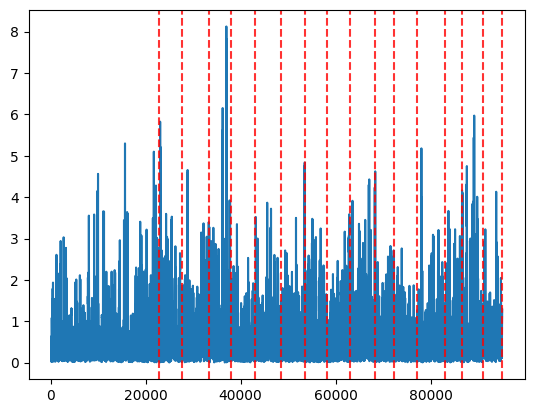

In [9]:
change_points_in_scores = change_points_in_scores = [cp // STEP for cp in change_indices]

plt.plot(
    timestamps[timestamps < change_indices[15]],
    scores_l2[timestamps < change_indices[15]],
)

for cp in change_indices[:16]:
    plt.axvline(
        cp,
        color='red',
        linestyle='--',
        alpha=0.8
    )

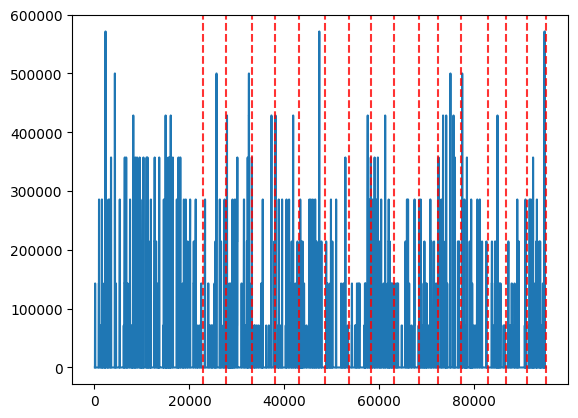

In [10]:
change_points_in_scores = change_points_in_scores = [cp // STEP for cp in change_indices]

plt.plot(
    timestamps[timestamps < change_indices[15]],
    scores_rel[timestamps < change_indices[15]],
)

for cp in change_indices[:16]:
    plt.axvline(
        cp,
        color='red',
        linestyle='--',
        alpha=0.8
    )

## mean plot

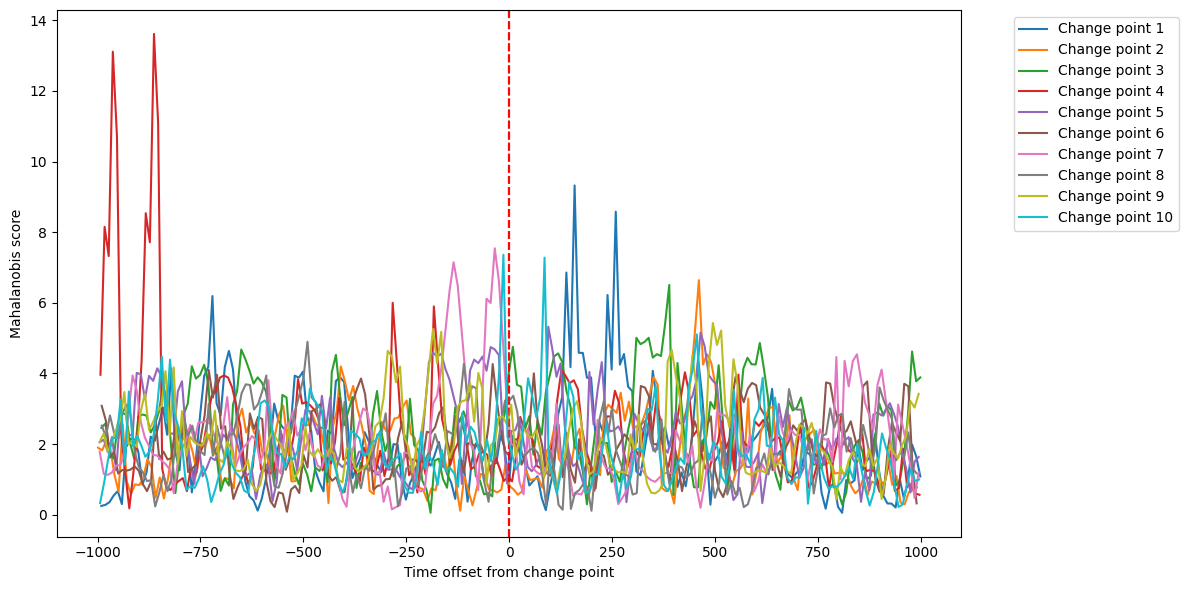

In [41]:
plt.figure(figsize=(12, 6))

for i in range(10):
    mask = (timestamps > change_indices[i] - 1000) & (timestamps < change_indices[i] + 1000)
    relative_time = timestamps[mask] - change_indices[i]  # offset from change point
    plt.plot(relative_time, scores_mahal[mask], label=f'Change point {i+1}')
    plt.axvline(0, color='red', linestyle='--', alpha=0.3)  # x=0 is the change point

plt.xlabel('Time offset from change point')
plt.ylabel('Mahalanobis score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# w=20, s=10

In [23]:
WINDOW = 20
STEP = 10

In [24]:
timestamps = []
scores_l2 = []
scores_mahal = []
scores_rel = []

change_points = np.array(change_indices)

# collect all feature vectors first
all_features = []

for t in range(WINDOW, len(data) - WINDOW, STEP):

    left_window = data[t-WINDOW:t]
    right_window = data[t:t+WINDOW]

    left_feat, feature_names = extract_features(left_window)
    right_feat, _ = extract_features(right_window)

    all_features.append(left_feat)
    all_features.append(right_feat)

all_features = np.array(all_features)

In [25]:
# covariance for Mahalanobis
cov = np.cov(all_features.T)

# regularization
cov += np.eye(cov.shape[0]) * 1e-6

cov_inv = pinv(cov) # need not be the general identity matrix, but it maps all column vectors of matrix to themselves


# actual scoring loop
for t in range(WINDOW, len(data) - WINDOW, STEP):

    left_window = data[t-WINDOW:t]
    right_window = data[t:t+WINDOW]

    left_feat, _ = extract_features(left_window)
    right_feat, _ = extract_features(right_window)

    # ----------------------------------------
    # scores
    # ----------------------------------------

    s_l2 = l2_distance(left_feat, right_feat)

    s_mahal = mahalanobis_distance(
        left_feat,
        right_feat,
        cov_inv
    )

    s_rel = relative_change(left_feat, right_feat)

    timestamps.append(t)

    scores_l2.append(s_l2)
    scores_mahal.append(s_mahal)
    scores_rel.append(s_rel)

timestamps = np.array(timestamps)

scores_l2 = np.array(scores_l2)
scores_mahal = np.array(scores_mahal)
scores_rel = np.array(scores_rel)

## plot

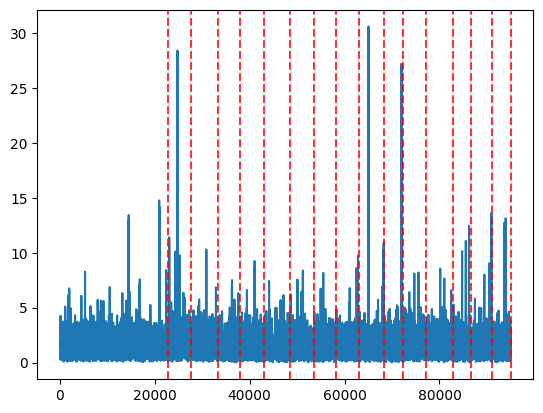

In [26]:
change_points_in_scores = change_points_in_scores = [cp // STEP for cp in change_indices]

plt.plot(
    timestamps[timestamps < change_indices[15]],
    scores_mahal[timestamps < change_indices[15]],
)

for cp in change_indices[:16]:
    plt.axvline(
        cp,
        color='red',
        linestyle='--',
        alpha=0.8
    )

## mean plot

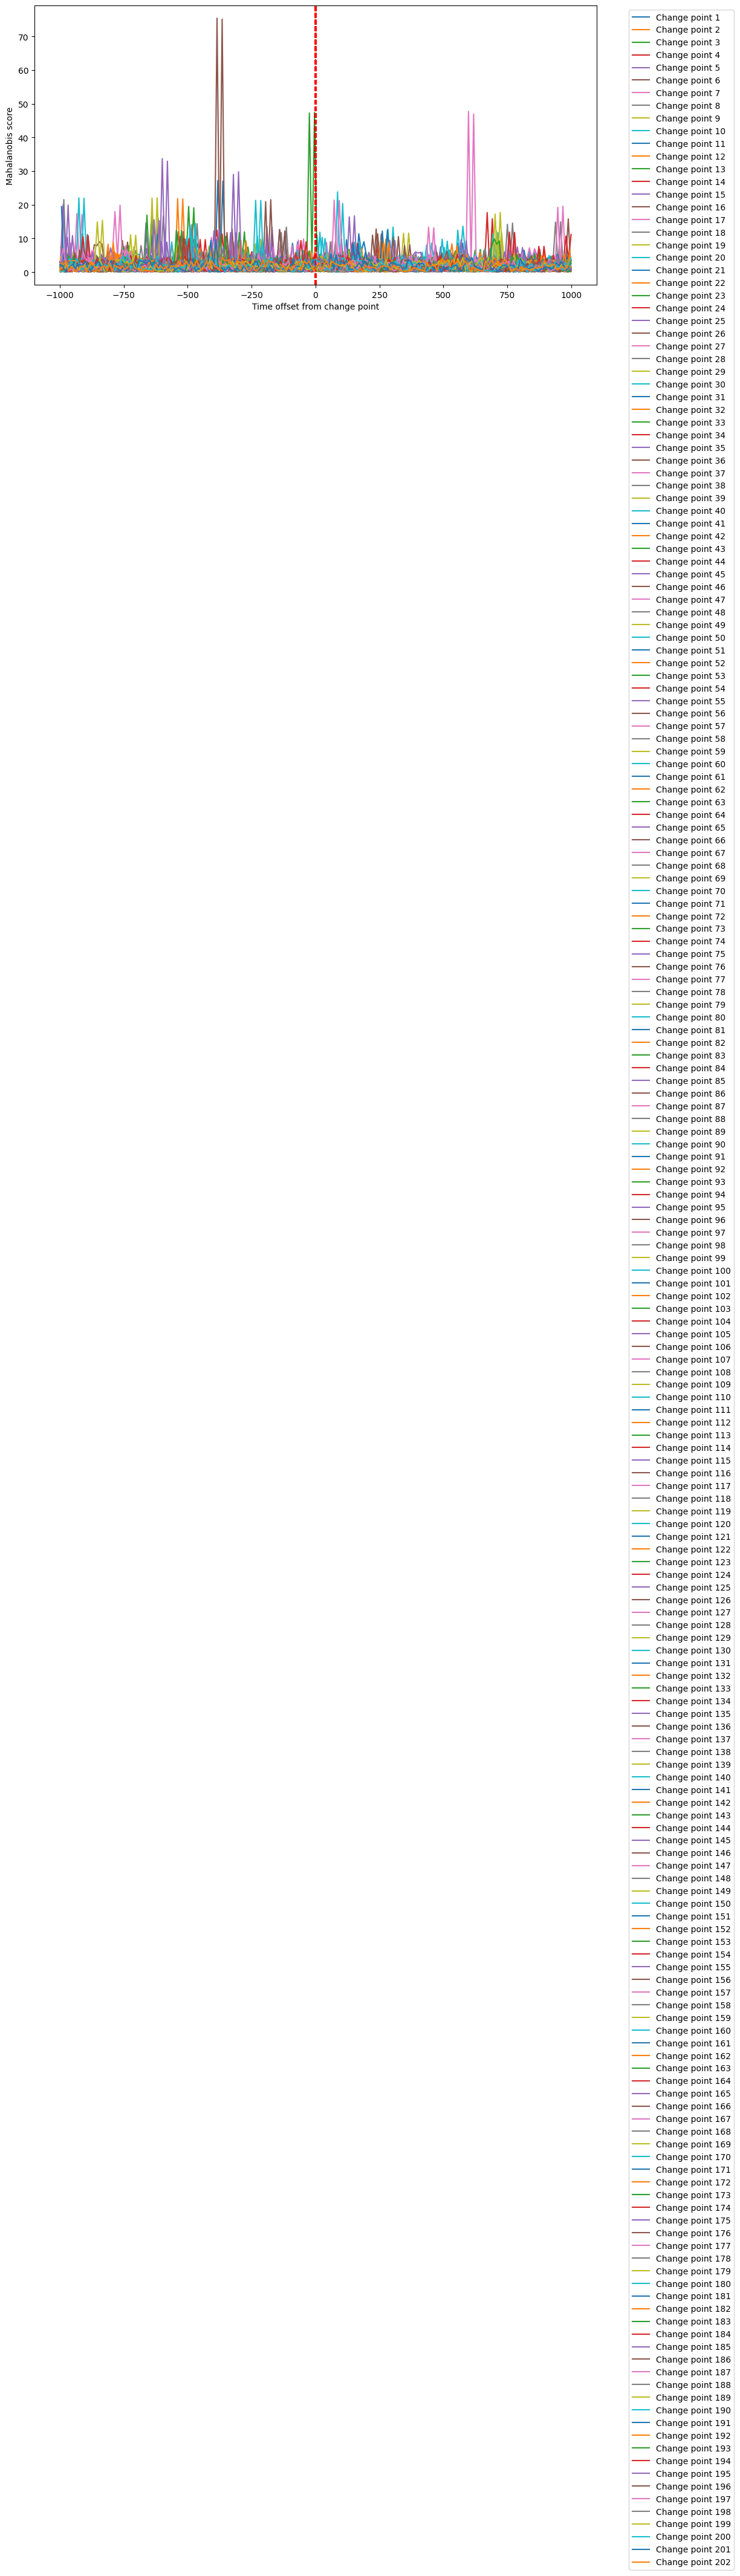

In [27]:
plt.figure(figsize=(12, 6))

for i in range(len(change_indices)//4):
    mask = (timestamps > change_indices[i] - 1000) & (timestamps < change_indices[i] + 1000)
    relative_time = timestamps[mask] - change_indices[i]  # offset from change point
    plt.plot(relative_time, scores_mahal[mask], label=f'Change point {i+1}')
    plt.axvline(0, color='red', linestyle='--', alpha=0.3)  # x=0 is the change point

plt.xlabel('Time offset from change point')
plt.ylabel('Mahalanobis score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# find optimal... maybe

## function with WINDOW and STEP parameters to optimize

In [11]:
def func(window, step):
    timestamps = []
    scores_mahal = []
    all_features = []

    for t in range(window, len(data) - window, step):

        left_window = data[t-window:t]
        right_window = data[t:t+window]

        left_feat, feature_names = extract_features(left_window)
        right_feat, _ = extract_features(right_window)

        all_features.append(left_feat)
        all_features.append(right_feat)

    all_features = np.array(all_features)

    # covariance for Mahalanobis
    cov = np.cov(all_features.T)

    # regularization
    cov += np.eye(cov.shape[0]) * 1e-6

    cov_inv = pinv(cov) # need not be the general identity matrix, but it maps all column vectors of matrix to themselves


    # actual scoring loop
    for t in range(window, len(data) - window, step):

        left_window = data[t-window:t]
        right_window = data[t:t+window]

        left_feat, _ = extract_features(left_window)
        right_feat, _ = extract_features(right_window)

        s_mahal = mahalanobis_distance(
            left_feat,
            right_feat,
            cov_inv
        )

        timestamps.append(t)
        scores_mahal.append(s_mahal)

    timestamps = np.array(timestamps)
    scores_mahal = np.array(scores_mahal)

    return timestamps, scores_mahal

## optimization condition - so that nearest timestamps to change are higher on average

In [12]:
import numpy as np
from skopt import gp_minimize
from skopt.space import Integer
from scipy.linalg import pinv

def compute_prominence(window, step):
    timestamps, scores = func(window, step)
    if len(scores) == 0:
        return -1e10

    half_window = 5 * step
    diffs = []

    for change_idx in change_indices:
        nearest_idx = np.argmin(np.abs(timestamps - change_idx))
        change_time = timestamps[nearest_idx]

        inner_mask = (timestamps >= change_time - half_window) & (timestamps <= change_time + half_window)
        outer_mask = ((timestamps >= change_time + half_window*3) & (timestamps <= change_time + half_window*6)) | \
                     ((timestamps >= change_time - half_window*6) & (timestamps <= change_time - half_window*3))

        if np.sum(inner_mask) >= 2 and np.sum(outer_mask) >= 2:
            diffs.append(np.mean(scores[inner_mask]) - np.mean(scores[outer_mask]))

    if len(diffs) == 0:
        return -1e10

    return np.mean(diffs) - 0.1 * np.std(diffs)

def objective(params):
    window, step = int(params[0]), int(params[1])
    if window < 10 or step < 1 or step > window or window >= len(data):
        return 1e10
    try:
        return -compute_prominence(window, step)
    except:
        return 1e10

In [13]:
space = [Integer(10, 500), Integer(1, 50)]
result = gp_minimize(objective, space, n_calls=50, n_initial_points=10, random_state=42)

In [17]:
optimal_window = int(result.x[0])
optimal_step = int(result.x[1])
print(f"Optimal: window={optimal_window}, step={optimal_step}, score={-result.fun:.4f}")

Optimal: window=310, step=1, score=-0.0296


In [18]:
timestamps, scores = func(optimal_window, optimal_step)

In [ ]:
plt.figure(figsize=(12, 6))
for i in range(min(10, len(change_indices))):
    mask = (timestamps > change_indices[i] - 1000) & (timestamps < change_indices[i] + 1000)
    plt.plot(timestamps[mask] - change_indices[i], scores[mask], alpha=0.7)
plt.axvline(0, color='red', linestyle='--', alpha=0.5)
plt.xlabel('Time offset from change point')
plt.ylabel('Mahalanobis score')
plt.title(f'Optimal: window={optimal_window}, step={optimal_step}')
plt.tight_layout()
plt.show()

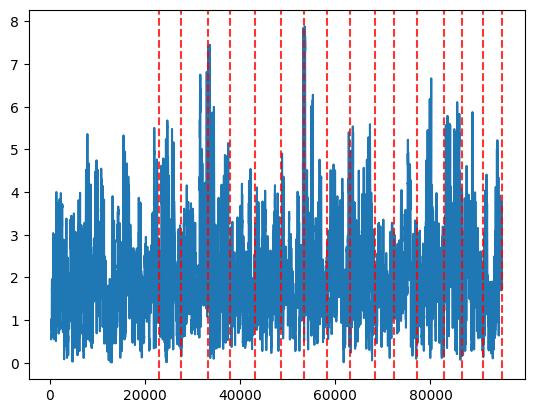

In [19]:
change_points_in_scores = change_points_in_scores = [cp // STEP for cp in change_indices]

plt.plot(
    timestamps[timestamps < change_indices[15]],
    scores[timestamps < change_indices[15]],
)

for cp in change_indices[:16]:
    plt.axvline(
        cp,
        color='red',
        linestyle='--',
        alpha=0.8
    )

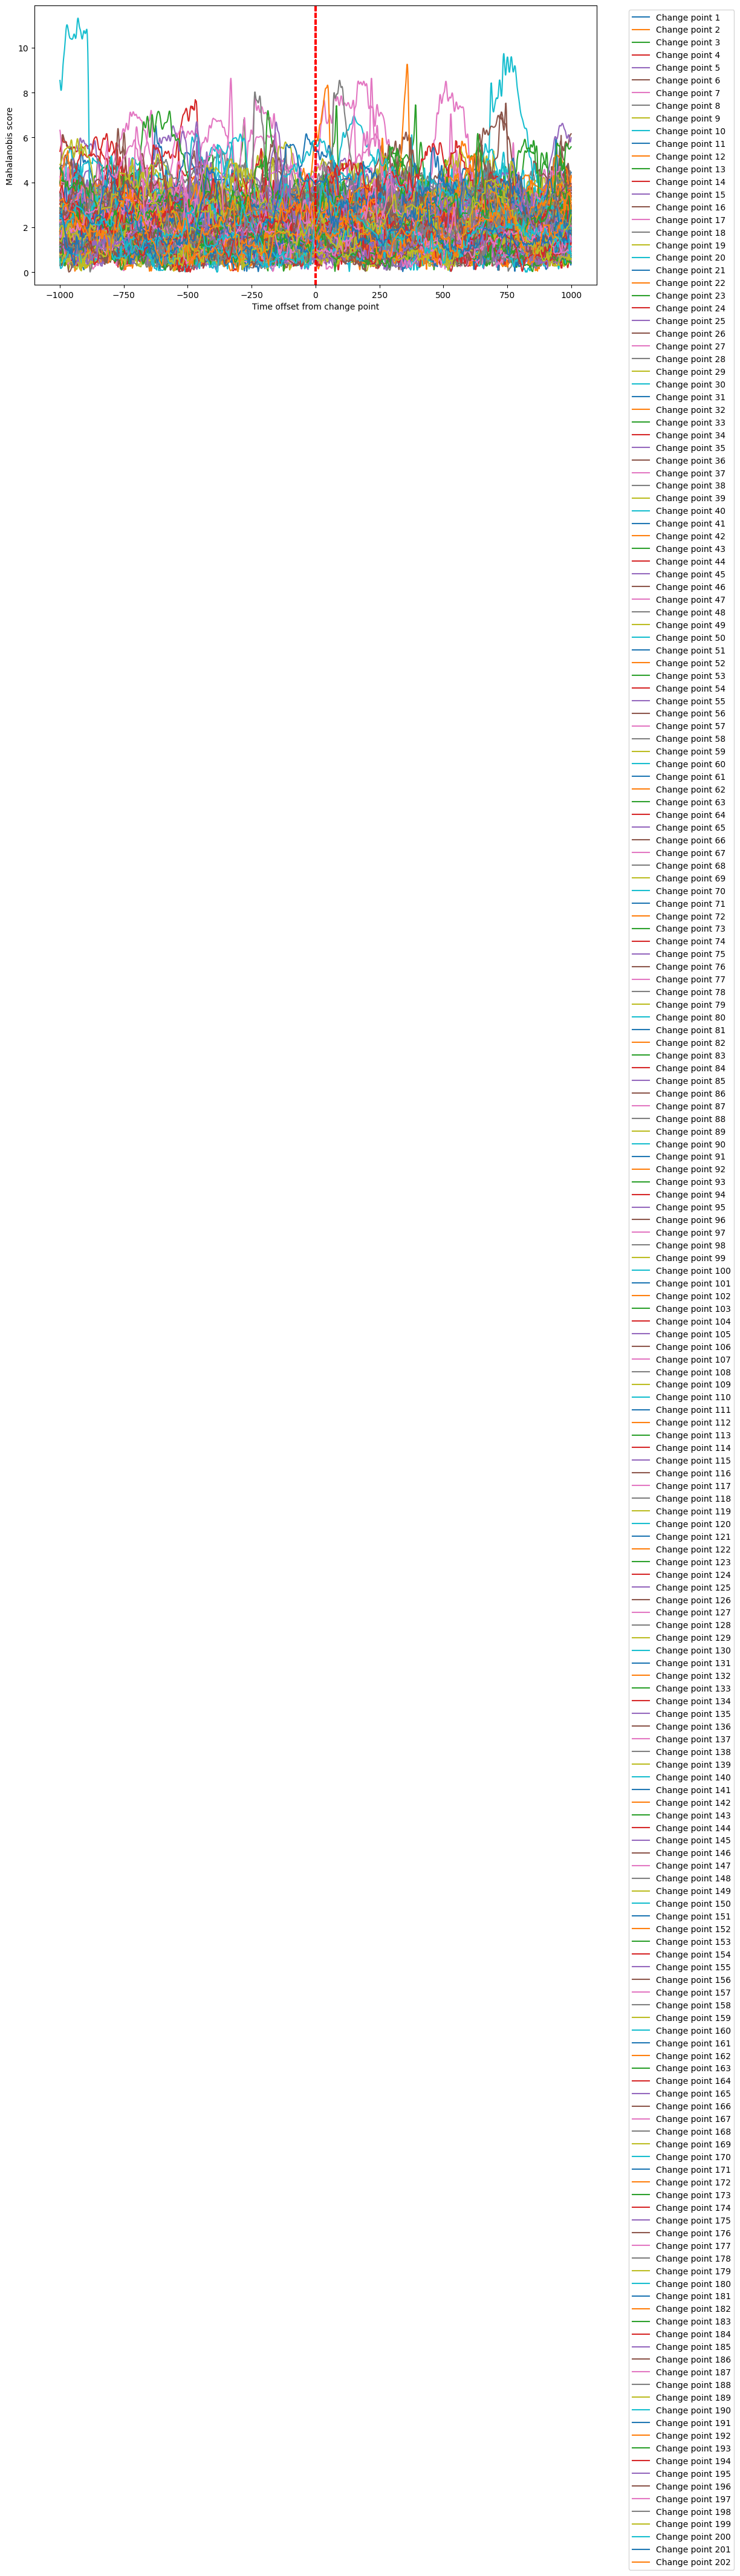

In [22]:
plt.figure(figsize=(12, 6))

for i in range(len(change_indices)//4):
    mask = (timestamps > change_indices[i] - 1000) & (timestamps < change_indices[i] + 1000)
    relative_time = timestamps[mask] - change_indices[i]  # offset from change point
    plt.plot(relative_time, scores[mask], label=f'Change point {i+1}')
    plt.axvline(0, color='red', linestyle='--', alpha=0.3)  # x=0 is the change point

plt.xlabel('Time offset from change point')
plt.ylabel('Mahalanobis score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()